In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path(r"C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research")

RAW_PATH = ROOT / "data" / "raw" / "factor_return_panel.csv"
PROCESSED_DIR = ROOT / "data" / "processed"
FIGURE_DIR = ROOT / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("CSV 路径：", RAW_PATH)
print("文件是否存在：", RAW_PATH.exists())

df = pd.read_csv(RAW_PATH, encoding="utf-8-sig")

print(df.head())
print(df.shape)
print(df.columns)

CSV 路径： C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\data\raw\factor_return_panel.csv
文件是否存在： True
  signal_date  entry_date   exit_date         code  momentum_60_5  next_ret  \
0  2016-01-29  2016-02-01  2016-03-01  000006.XSHE      -0.320041  0.133913   
1  2016-01-29  2016-02-01  2016-03-01  000012.XSHE      -0.064145 -0.025907   
2  2016-01-29  2016-02-01  2016-03-01  000021.XSHE      -0.265709  0.010929   
3  2016-01-29  2016-02-01  2016-03-01  000030.XSHE      -0.218487 -0.034188   
4  2016-01-29  2016-02-01  2016-03-01  000031.XSHE      -0.312457  0.162011   

   benchmark_ret  
0       0.013733  
1       0.013733  
2       0.013733  
3       0.013733  
4       0.013733  
(57865, 7)
Index(['signal_date', 'entry_date', 'exit_date', 'code', 'momentum_60_5',
       'next_ret', 'benchmark_ret'],
      dtype='object')


In [6]:
# =========================
# 1. 基础设置
# =========================

FACTOR_COL = "momentum_60_5"
RET_COL = "next_ret"
BENCH_COL = "benchmark_ret"
DATE_COL = "signal_date"
N_GROUPS = 5

panel = df.copy()

panel[DATE_COL] = pd.to_datetime(panel[DATE_COL])
panel["entry_date"] = pd.to_datetime(panel["entry_date"])
panel["exit_date"] = pd.to_datetime(panel["exit_date"])

panel = panel.dropna(subset=[FACTOR_COL, RET_COL])
panel = panel.sort_values([DATE_COL, "code"]).reset_index(drop=True)

print("=" * 80)
print("Basic information")
print("=" * 80)
print("Shape:", panel.shape)
print("Date range:", panel[DATE_COL].min().date(), "to", panel[DATE_COL].max().date())
print("Number of stocks:", panel["code"].nunique())
print("Average stocks per month:", panel.groupby(DATE_COL)["code"].nunique().mean())
print()
print("Missing values:")
print(panel.isna().sum())


# =========================
# 2. 每个月按动量因子分组
# =========================

def assign_groups_one_month(group):
    """
    每个月横截面分成5组：
    G1 = 动量最低20%
    G5 = 动量最高20%
    """
    group = group.copy()
    
    if len(group) < N_GROUPS:
        group["factor_group"] = np.nan
        return group
    
    # 用 rank 避免 qcut 因重复值报错
    rank_value = group[FACTOR_COL].rank(method="first", ascending=True)
    labels = [f"G{i}" for i in range(1, N_GROUPS + 1)]
    group["factor_group"] = pd.qcut(rank_value, q=N_GROUPS, labels=labels)
    
    return group


panel_grouped = (
    panel.groupby(DATE_COL, group_keys=False)
    .apply(assign_groups_one_month)
    .dropna(subset=["factor_group"])
)

panel_grouped.to_csv(
    PROCESSED_DIR / "panel_with_factor_group.csv",
    index=False,
    encoding="utf-8-sig"
)

print()
print("=" * 80)
print("Grouped panel")
print("=" * 80)
print(panel_grouped.head())
print(panel_grouped.shape)


# =========================
# 3. 分组收益
# =========================

group_return = (
    panel_grouped
    .groupby([DATE_COL, "factor_group"], observed=False)[RET_COL]
    .mean()
    .unstack()
    .sort_index()
)

group_return.to_csv(
    PROCESSED_DIR / "monthly_group_return.csv",
    encoding="utf-8-sig"
)

average_group_return = group_return.mean().to_frame("average_monthly_return")
average_group_return["annualized_simple"] = average_group_return["average_monthly_return"] * 12

print()
print("=" * 80)
print("Average group return")
print("=" * 80)
display(average_group_return)


# =========================
# 4. RankIC
# =========================

def calculate_rank_ic(group):
    """
    RankIC = 因子值和下一期收益率的 Spearman 秩相关。
    这里不用 scipy，直接用 pandas corr(method='spearman')。
    """
    if len(group) < 20:
        return np.nan
    
    x = group[FACTOR_COL]
    y = group[RET_COL]
    
    if x.nunique() <= 1 or y.nunique() <= 1:
        return np.nan
    
    return x.corr(y, method="spearman")


rank_ic = panel.groupby(DATE_COL).apply(calculate_rank_ic)
rank_ic.name = "rank_ic"

rank_ic.to_csv(
    PROCESSED_DIR / "monthly_rank_ic.csv",
    encoding="utf-8-sig"
)

print()
print("=" * 80)
print("RankIC summary")
print("=" * 80)
print(rank_ic.describe())
print("RankIC mean:", rank_ic.mean())
print("RankIC positive ratio:", (rank_ic > 0).mean())


# =========================
# 5. 绩效指标函数
# =========================

def max_drawdown(net_value):
    running_max = net_value.cummax()
    drawdown = net_value / running_max - 1
    return drawdown.min()


def performance_summary(returns, name):
    """
    输入月度收益率序列，输出绩效指标。
    """
    returns = returns.dropna()
    
    if len(returns) == 0:
        return {
            "name": name,
            "months": 0,
            "total_return": np.nan,
            "annual_return": np.nan,
            "annual_volatility": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
            "win_rate": np.nan,
        }
    
    net_value = (1 + returns).cumprod()
    
    total_return = net_value.iloc[-1] - 1
    annual_return = net_value.iloc[-1] ** (12 / len(returns)) - 1
    annual_volatility = returns.std(ddof=1) * np.sqrt(12)
    
    if annual_volatility == 0 or np.isnan(annual_volatility):
        sharpe = np.nan
    else:
        sharpe = annual_return / annual_volatility
    
    return {
        "name": name,
        "months": len(returns),
        "total_return": total_return,
        "annual_return": annual_return,
        "annual_volatility": annual_volatility,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown(net_value),
        "win_rate": (returns > 0).mean(),
    }


# =========================
# 6. 第一版策略：买入动量最高20%
# =========================

strategy_ret = group_return["G5"].dropna()
low_momentum_ret = group_return["G1"].dropna()
long_short_ret = (group_return["G5"] - group_return["G1"]).dropna()

benchmark_ret = (
    panel.groupby(DATE_COL)[BENCH_COL]
    .first()
    .reindex(strategy_ret.index)
    .dropna()
)

# 对齐日期
common_index = strategy_ret.index.intersection(benchmark_ret.index)

strategy_ret = strategy_ret.loc[common_index]
benchmark_ret = benchmark_ret.loc[common_index]
low_momentum_ret = low_momentum_ret.reindex(common_index)
long_short_ret = long_short_ret.reindex(common_index)

perf = pd.DataFrame([
    performance_summary(strategy_ret, "G5_top_momentum"),
    performance_summary(low_momentum_ret, "G1_low_momentum"),
    performance_summary(long_short_ret, "G5_minus_G1"),
    performance_summary(benchmark_ret, "benchmark_CSI500"),
])

perf.to_csv(
    PROCESSED_DIR / "performance_summary_no_cost.csv",
    index=False,
    encoding="utf-8-sig"
)

print()
print("=" * 80)
print("Performance summary, no transaction cost")
print("=" * 80)
display(perf)


# =========================
# 7. 保存关键收益序列
# =========================

returns_df = pd.DataFrame({
    "strategy_ret": strategy_ret,
    "benchmark_ret": benchmark_ret,
    "low_momentum_ret": low_momentum_ret,
    "long_short_ret": long_short_ret,
})

returns_df.to_csv(
    PROCESSED_DIR / "strategy_returns_no_cost.csv",
    encoding="utf-8-sig"
)

print()
print("收益序列已保存：")
print(PROCESSED_DIR / "strategy_returns_no_cost.csv")

Basic information
Shape: (57865, 7)
Date range: 2016-01-29 to 2025-10-31
Number of stocks: 1229
Average stocks per month: 490.3813559322034

Missing values:
signal_date      0
entry_date       0
exit_date        0
code             0
momentum_60_5    0
next_ret         0
benchmark_ret    0
dtype: int64


C:\Users\yue\AppData\Local\Temp\ipykernel_27756\3039682580.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_groups_one_month)



Grouped panel
  signal_date entry_date  exit_date         code  momentum_60_5  next_ret  \
0  2016-01-29 2016-02-01 2016-03-01  000006.XSHE      -0.320041  0.133913   
1  2016-01-29 2016-02-01 2016-03-01  000012.XSHE      -0.064145 -0.025907   
2  2016-01-29 2016-02-01 2016-03-01  000021.XSHE      -0.265709  0.010929   
3  2016-01-29 2016-02-01 2016-03-01  000030.XSHE      -0.218487 -0.034188   
4  2016-01-29 2016-02-01 2016-03-01  000031.XSHE      -0.312457  0.162011   

   benchmark_ret factor_group  
0       0.013733           G1  
1       0.013733           G5  
2       0.013733           G2  
3       0.013733           G3  
4       0.013733           G1  
(57865, 8)

Average group return


,average_monthly_return,annualized_simple
factor_group,,
G1,0.005352,0.064222
G2,0.006555,0.078659
G3,0.007201,0.086406
G4,0.007602,0.091221
G5,0.005993,0.071910



RankIC summary
count    118.000000
mean      -0.023207
std        0.174500
min       -0.462501
25%       -0.141094
50%       -0.013507
75%        0.111093
max        0.437894
Name: rank_ic, dtype: float64
RankIC mean: -0.023206788510618137
RankIC positive ratio: 0.4576271186440678

Performance summary, no transaction cost


C:\Users\yue\AppData\Local\Temp\ipykernel_27756\3039682580.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank_ic = panel.groupby(DATE_COL).apply(calculate_rank_ic)


,name,months,total_return,annual_return,annual_volatility,sharpe,max_drawdown,win_rate
0,G5_top_momentum,118,0.537868,0.044741,0.241725,0.185091,-0.428414,0.516949
1,G1_low_momentum,118,0.343215,0.030461,0.270551,0.112591,-0.439283,0.491525
2,G5_minus_G1,118,-0.045515,-0.004726,0.158142,-0.029885,-0.351393,0.500000
3,benchmark_CSI500,118,0.315281,0.028261,0.233180,0.121201,-0.381752,0.516949



收益序列已保存：
C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\data\processed\strategy_returns_no_cost.csv


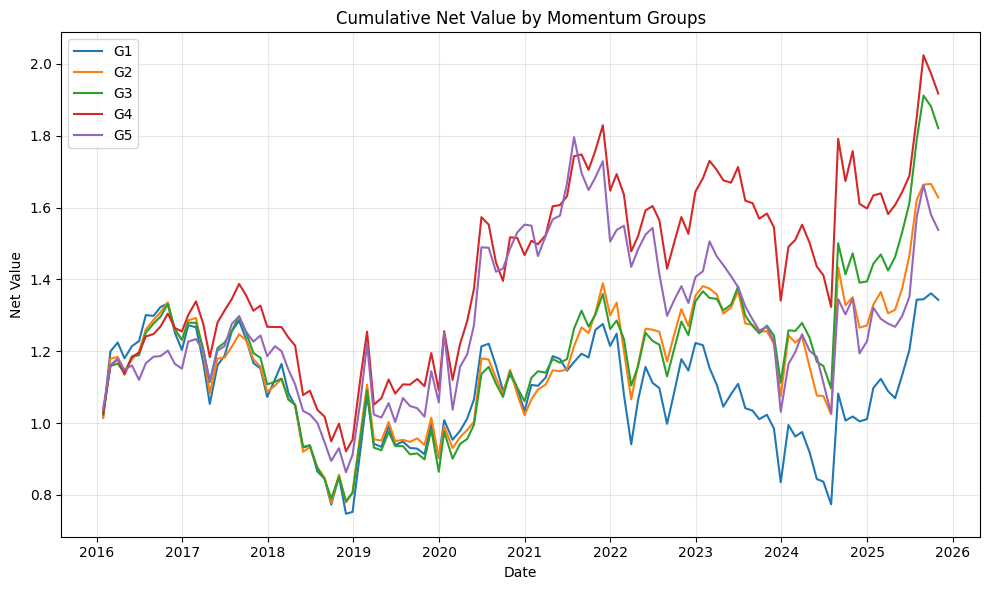

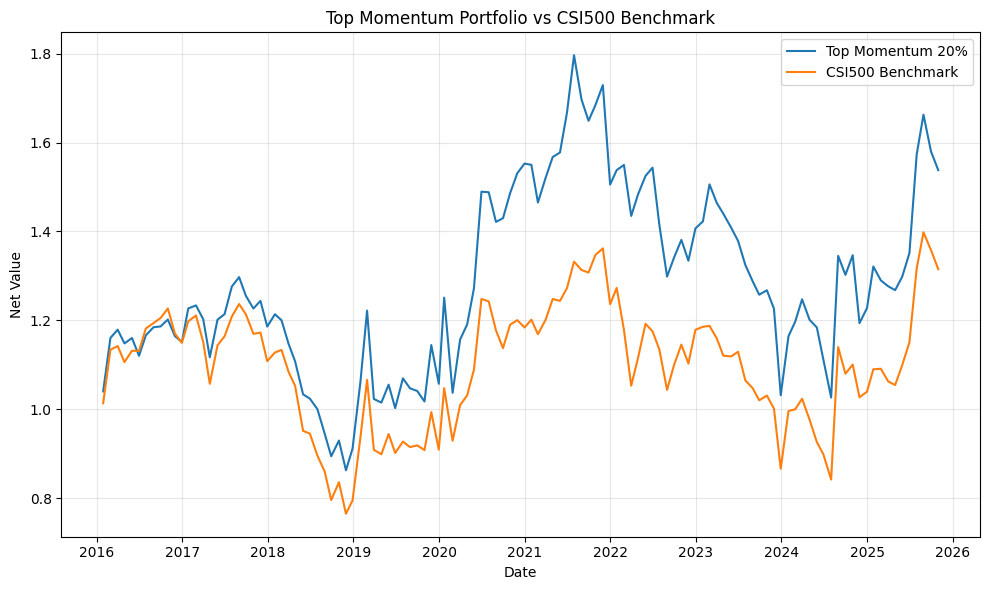

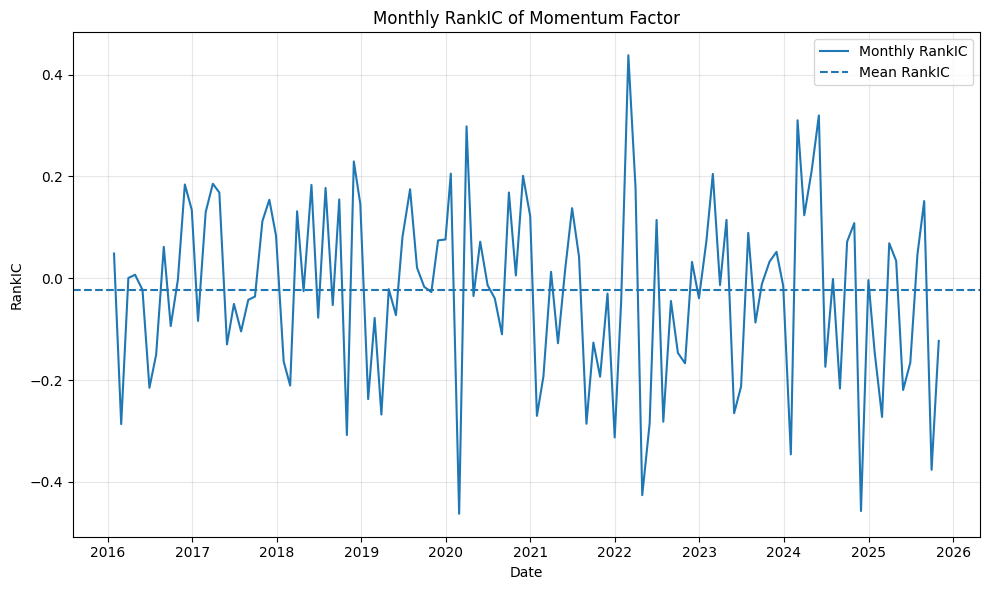

图像已保存到： C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\reports\figures
1. C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\reports\figures\group_net_value.png
2. C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\reports\figures\strategy_vs_benchmark_no_cost.png
3. C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\reports\figures\monthly_rank_ic.png


In [7]:
# =========================
# 1. 分组净值曲线
# =========================

group_net_value = (1 + group_return).cumprod()

plt.figure(figsize=(10, 6))
for col in group_net_value.columns:
    plt.plot(group_net_value.index, group_net_value[col], label=col)

plt.title("Cumulative Net Value by Momentum Groups")
plt.xlabel("Date")
plt.ylabel("Net Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "group_net_value.png", dpi=300)
plt.show()


# =========================
# 2. 策略 vs 中证500
# =========================

strategy_net_value = (1 + strategy_ret).cumprod()
benchmark_net_value = (1 + benchmark_ret).cumprod()

plt.figure(figsize=(10, 6))
plt.plot(strategy_net_value.index, strategy_net_value, label="Top Momentum 20%")
plt.plot(benchmark_net_value.index, benchmark_net_value, label="CSI500 Benchmark")

plt.title("Top Momentum Portfolio vs CSI500 Benchmark")
plt.xlabel("Date")
plt.ylabel("Net Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "strategy_vs_benchmark_no_cost.png", dpi=300)
plt.show()


# =========================
# 3. RankIC 时间序列
# =========================

plt.figure(figsize=(10, 6))
plt.plot(rank_ic.index, rank_ic.values, label="Monthly RankIC")
plt.axhline(rank_ic.mean(), linestyle="--", label="Mean RankIC")

plt.title("Monthly RankIC of Momentum Factor")
plt.xlabel("Date")
plt.ylabel("RankIC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "monthly_rank_ic.png", dpi=300)
plt.show()


print("图像已保存到：", FIGURE_DIR)
print("1.", FIGURE_DIR / "group_net_value.png")
print("2.", FIGURE_DIR / "strategy_vs_benchmark_no_cost.png")
print("3.", FIGURE_DIR / "monthly_rank_ic.png")

In [9]:
print("=" * 80)
print("Average group return")
print("=" * 80)
display(average_group_return)

print("=" * 80)
print("RankIC summary")
print("=" * 80)
print(rank_ic.describe())
print("RankIC mean:", rank_ic.mean())
print("RankIC positive ratio:", (rank_ic > 0).mean())

print("=" * 80)
print("Performance summary, no transaction cost")
print("=" * 80)
display(perf)

Average group return


,average_monthly_return,annualized_simple
factor_group,,
G1,0.005352,0.064222
G2,0.006555,0.078659
G3,0.007201,0.086406
G4,0.007602,0.091221
G5,0.005993,0.071910


RankIC summary
count    118.000000
mean      -0.023207
std        0.174500
min       -0.462501
25%       -0.141094
50%       -0.013507
75%        0.111093
max        0.437894
Name: rank_ic, dtype: float64
RankIC mean: -0.023206788510618137
RankIC positive ratio: 0.4576271186440678
Performance summary, no transaction cost


,name,months,total_return,annual_return,annual_volatility,sharpe,max_drawdown,win_rate
0,G5_top_momentum,118,0.537868,0.044741,0.241725,0.185091,-0.428414,0.516949
1,G1_low_momentum,118,0.343215,0.030461,0.270551,0.112591,-0.439283,0.491525
2,G5_minus_G1,118,-0.045515,-0.004726,0.158142,-0.029885,-0.351393,0.500000
3,benchmark_CSI500,118,0.315281,0.028261,0.233180,0.121201,-0.381752,0.516949


In [10]:
# 先复制一份分组收益数据，避免修改原始 group_return
annual_group_return = group_return.copy()

# group_return 的索引是 signal_date，把它转成年份
annual_group_return["year"] = annual_group_return.index.year

# 按年份分组，计算每组当年的复合收益
# 例如某一年每月收益为 r1, r2, ..., r12
# 年收益 = (1+r1)(1+r2)...(1+r12)-1
annual_group_return = (
    annual_group_return
    .groupby("year")
    .apply(lambda x: (1 + x.drop(columns="year")).prod() - 1)
)

annual_group_return

C:\Users\yue\AppData\Local\Temp\ipykernel_27756\1975319345.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (1 + x.drop(columns="year")).prod() - 1)


factor_group,G1,G2,G3,G4,G5
year,,,,,
2016,0.203568,0.231673,0.232380,0.255112,0.151429
2017,-0.108689,-0.117597,-0.101222,0.010291,0.030186
2018,-0.298554,-0.258595,-0.272364,-0.247942,-0.231356
2019,0.199071,0.122010,0.072530,0.144193,0.159995
2020,0.145232,0.129998,0.227417,0.344976,0.468042
2021,0.175785,0.272488,0.189385,0.122602,-0.030360
2022,0.006622,0.042240,0.061073,-0.001798,-0.065560
2023,-0.317046,-0.206867,-0.169135,-0.184503,-0.266620
2024,0.210360,0.183589,0.253317,0.191186,0.189974


In [11]:
# 每一年收益最高的分组
best_group_by_year = annual_group_return.idxmax(axis=1)

# 每一年最高收益是多少
best_return_by_year = annual_group_return.max(axis=1)

# 合并成一个表，方便观察
best_group_summary = pd.DataFrame({
    "best_group": best_group_by_year,
    "best_return": best_return_by_year
})

best_group_summary

,best_group,best_return
year,,
2016,G4,0.255112
2017,G5,0.030186
2018,G5,-0.231356
2019,G1,0.199071
2020,G5,0.468042
2021,G2,0.272488
2022,G3,0.061073
2023,G3,-0.169135
2024,G3,0.253317


In [12]:
# 统计每个分组成为年度最优的次数
best_group_count = best_group_by_year.value_counts().sort_index()

best_group_count

G1    2
G2    1
G3    3
G4    1
G5    3
Name: count, dtype: int64

In [13]:
# 提取 G4 和 G5 的月度收益
g4_ret = group_return["G4"].dropna()
g5_ret = group_return["G5"].dropna()

# 对齐日期
common_dates = g4_ret.index.intersection(g5_ret.index)
g4_ret = g4_ret.loc[common_dates]
g5_ret = g5_ret.loc[common_dates]

# 计算 G4 - G5 的月度收益差
g4_minus_g5 = g4_ret - g5_ret

print("G4 月均收益:", g4_ret.mean())
print("G5 月均收益:", g5_ret.mean())
print("G4-G5 月均收益差:", g4_minus_g5.mean())
print("G4 跑赢 G5 的月份比例:", (g4_minus_g5 > 0).mean())

G4 月均收益: 0.007601726888017526
G5 月均收益: 0.005992502891738206
G4-G5 月均收益差: 0.0016092239962793207
G4 跑赢 G5 的月份比例: 0.5423728813559322


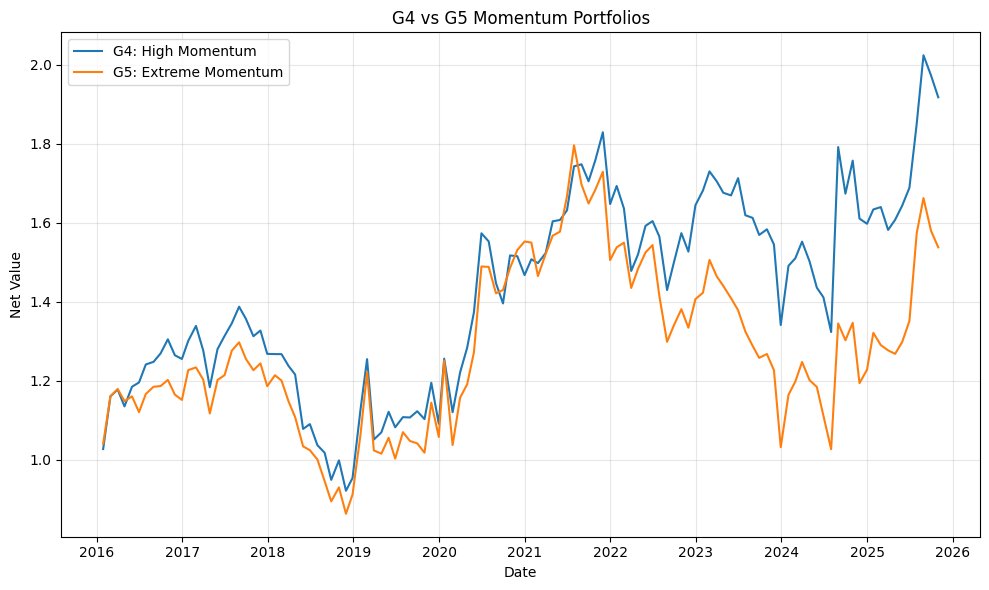

In [14]:
# 计算净值曲线
g4_net_value = (1 + g4_ret).cumprod()
g5_net_value = (1 + g5_ret).cumprod()

plt.figure(figsize=(10, 6))

plt.plot(g4_net_value.index, g4_net_value, label="G4: High Momentum")
plt.plot(g5_net_value.index, g5_net_value, label="G5: Extreme Momentum")

plt.title("G4 vs G5 Momentum Portfolios")
plt.xlabel("Date")
plt.ylabel("Net Value")
plt.legend()
plt.grid(True, alpha=0.3)

# 保存图片
plt.tight_layout()
plt.savefig(FIGURE_DIR / "g4_vs_g5_net_value.png", dpi=300)

plt.show()

In [15]:
def build_equal_weight_portfolio(panel_grouped, group_label):
    """
    构造某个分组的等权持仓表。

    参数：
    panel_grouped : 已经完成因子分组的数据
    group_label   : 例如 "G4" 或 "G5"

    返回：
    weights : 行是 signal_date，列是股票代码，值是目标权重
              如果某只股票当月不在组合里，权重就是 0
    """
    
    # 只保留目标分组，例如只保留 G4 组股票
    selected = panel_grouped[panel_grouped["factor_group"] == group_label].copy()
    
    # 计算每个信号日入选股票数量
    stock_count = selected.groupby("signal_date")["code"].transform("count")
    
    # 等权持有：每只股票权重 = 1 / 当月入选股票数量
    selected["weight"] = 1 / stock_count
    
    # 转成宽表：
    # 行：signal_date
    # 列：code
    # 值：weight
    weights = selected.pivot(
        index="signal_date",
        columns="code",
        values="weight"
    )
    
    # 没有持仓的股票权重填 0
    weights = weights.fillna(0)
    
    return weights

In [16]:
g4_weights = build_equal_weight_portfolio(panel_grouped, "G4")
g5_weights = build_equal_weight_portfolio(panel_grouped, "G5")

print("G4 weights shape:", g4_weights.shape)
print("G5 weights shape:", g5_weights.shape)

display(g4_weights.head())

G4 weights shape: (118, 1172)
G5 weights shape: (118, 1138)


code,000006.XSHE,000008.XSHE,000009.XSHE,000012.XSHE,000021.XSHE,000025.XSHE,000027.XSHE,000028.XSHE,000030.XSHE,000031.XSHE,...,688608.XSHG,688617.XSHG,688676.XSHG,688728.XSHG,688772.XSHG,688777.XSHG,688778.XSHG,688779.XSHG,688819.XSHG,689009.XSHG
signal_date,,,,,,,,,,,,,,,,,,,,,
2016-01-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-02-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.010989,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-03-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-04-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-05-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
print("G4 每月权重和：")
print(g4_weights.sum(axis=1).head())

print("G5 每月权重和：")
print(g5_weights.sum(axis=1).head())

G4 每月权重和：
signal_date
2016-01-29    1.0
2016-02-29    1.0
2016-03-31    1.0
2016-04-29    1.0
2016-05-31    1.0
dtype: float64
G5 每月权重和：
signal_date
2016-01-29    1.0
2016-02-29    1.0
2016-03-31    1.0
2016-04-29    1.0
2016-05-31    1.0
dtype: float64


In [18]:
def build_return_matrix(panel_grouped):
    """
    构造个股下一期收益矩阵。

    返回：
    ret_matrix : 行是 signal_date，列是股票代码，值是 next_ret
    """
    
    ret_matrix = panel_grouped.pivot(
        index="signal_date",
        columns="code",
        values="next_ret"
    )
    
    return ret_matrix

In [19]:
ret_matrix = build_return_matrix(panel_grouped)

print("Return matrix shape:", ret_matrix.shape)
display(ret_matrix.head())

Return matrix shape: (118, 1229)


code,000006.XSHE,000008.XSHE,000009.XSHE,000012.XSHE,000021.XSHE,000025.XSHE,000027.XSHE,000028.XSHE,000030.XSHE,000031.XSHE,...,688676.XSHG,688690.XSHG,688702.XSHG,688728.XSHG,688772.XSHG,688777.XSHG,688778.XSHG,688779.XSHG,688819.XSHG,689009.XSHG
signal_date,,,,,,,,,,,,,,,,,,,,,
2016-01-29,0.133913,NaN,NaN,-0.025907,0.010929,NaN,NaN,NaN,-0.034188,0.162011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-02-29,0.018405,NaN,NaN,0.067376,0.125676,NaN,NaN,NaN,0.117994,0.007692,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-31,-0.019578,NaN,NaN,0.084718,0.022809,NaN,NaN,0.145450,0.023747,-0.085878,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-04-29,-0.086022,NaN,NaN,-0.004594,-0.066901,NaN,NaN,-0.100083,-0.064433,-0.036534,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-05-31,0.008403,NaN,NaN,0.006154,0.251572,NaN,NaN,0.032437,0.016529,-0.039003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
def calculate_portfolio_return(weights, ret_matrix):
    """
    根据持仓权重和个股收益，计算组合每期收益。

    组合收益 = sum(每只股票权重 × 每只股票下一期收益)
    """
    
    # 对齐日期和股票代码，避免矩阵错位
    common_dates = weights.index.intersection(ret_matrix.index)
    common_codes = weights.columns.intersection(ret_matrix.columns)
    
    weights_aligned = weights.loc[common_dates, common_codes]
    returns_aligned = ret_matrix.loc[common_dates, common_codes]
    
    # 个股收益缺失时，简单按 0 处理。
    # 更严格的做法是剔除该股票并重新归一化权重，后面可以改进。
    returns_aligned = returns_aligned.fillna(0)
    
    # 每个月组合收益 = 权重和收益逐元素相乘，然后按股票求和
    portfolio_ret = (weights_aligned * returns_aligned).sum(axis=1)
    
    return portfolio_ret

In [21]:
g4_ret_weighted = calculate_portfolio_return(g4_weights, ret_matrix)
g5_ret_weighted = calculate_portfolio_return(g5_weights, ret_matrix)

print("G4 权重法月均收益:", g4_ret_weighted.mean())
print("G5 权重法月均收益:", g5_ret_weighted.mean())

print("之前 group_return 里的 G4 月均收益:", group_return["G4"].mean())
print("之前 group_return 里的 G5 月均收益:", group_return["G5"].mean())

G4 权重法月均收益: 0.007601726888017526
G5 权重法月均收益: 0.005992502891738205
之前 group_return 里的 G4 月均收益: 0.007601726888017526
之前 group_return 里的 G5 月均收益: 0.005992502891738206


In [22]:
def align_weight_and_return(weights, ret_matrix):
    """
    对齐持仓权重矩阵和收益矩阵。

    weights:
        行 = signal_date
        列 = 股票代码
        值 = 目标持仓权重

    ret_matrix:
        行 = signal_date
        列 = 股票代码
        值 = 下一期个股收益

    返回：
        weights_aligned, returns_aligned
    """
    
    # 取共同的日期
    common_dates = weights.index.intersection(ret_matrix.index)
    
    # 取共同出现过的股票代码
    common_codes = weights.columns.union(ret_matrix.columns)
    
    # 权重缺失说明不持仓，填 0
    weights_aligned = weights.reindex(
        index=common_dates,
        columns=common_codes
    ).fillna(0)
    
    # 收益缺失先填 0
    # 这里是简化处理：如果某股票下一期收益缺失，就假设该部分收益为 0
    returns_aligned = ret_matrix.reindex(
        index=common_dates,
        columns=common_codes
    ).fillna(0)
    
    return weights_aligned, returns_aligned

In [23]:
g4_w, g4_r = align_weight_and_return(g4_weights, ret_matrix)
g5_w, g5_r = align_weight_and_return(g5_weights, ret_matrix)

print("G4 aligned weights shape:", g4_w.shape)
print("G4 aligned returns shape:", g4_r.shape)

print("G5 aligned weights shape:", g5_w.shape)
print("G5 aligned returns shape:", g5_r.shape)

print("G4 权重和前5行：")
print(g4_w.sum(axis=1).head())

G4 aligned weights shape: (118, 1229)
G4 aligned returns shape: (118, 1229)
G5 aligned weights shape: (118, 1229)
G5 aligned returns shape: (118, 1229)
G4 权重和前5行：
signal_date
2016-01-29    1.0
2016-02-29    1.0
2016-03-31    1.0
2016-04-29    1.0
2016-05-31    1.0
dtype: float64


In [24]:
def calculate_turnover_and_cost(weights, ret_matrix, cost_rate=0.001):
    """
    计算组合每期毛收益、换手率、交易成本和扣费后收益。

    cost_rate:
        每交易 1 元资产需要支付的成本。
        这里先假设为 0.001，即 0.1%。
        这是简化设定，包含手续费、滑点、冲击成本等。
    """
    
    weights, returns = align_weight_and_return(weights, ret_matrix)
    
    dates = weights.index
    
    gross_returns = []
    trade_values = []
    one_way_turnovers = []
    costs = []
    net_returns = []
    
    # 上一期调仓后的目标权重
    prev_weight = None
    
    for i, date in enumerate(dates):
        # 当前期目标权重
        target_weight = weights.loc[date]
        
        # 当前期个股收益
        period_return = returns.loc[date]
        
        # 当前期组合毛收益
        gross_ret = (target_weight * period_return).sum()
        
        if i == 0:
            # 第一期从现金建仓
            # 买入整个组合，所以交易金额约等于 1
            trade_value = target_weight.abs().sum()
        else:
            # 上一期个股收益
            prev_period_return = returns.iloc[i - 1]
            
            # 上一期组合收益
            prev_portfolio_return = (prev_weight * prev_period_return).sum()
            
            # 上一期持仓经过涨跌后的调仓前权重
            # 分子：每只股票原权重 × (1 + 个股收益)
            # 分母：整个组合净值增长倍数
            pre_trade_weight = (
                prev_weight * (1 + prev_period_return)
                / (1 + prev_portfolio_return)
            )
            
            # 当前需要交易的金额比例
            # 例如从 0.03 调到 0.05，需要买 0.02
            # 从 0.04 调到 0，需要卖 0.04
            trade_value = (target_weight - pre_trade_weight).abs().sum()
        
        # 常见意义上的单边换手率
        # 因为买卖两边合计 trade_value，
        # 一般 one-way turnover = trade_value / 2
        one_way_turnover = trade_value / 2
        
        # 交易成本
        transaction_cost = trade_value * cost_rate
        
        # 扣费后收益
        # 先付成本，再获得组合收益
        net_ret = (1 - transaction_cost) * (1 + gross_ret) - 1
        
        gross_returns.append(gross_ret)
        trade_values.append(trade_value)
        one_way_turnovers.append(one_way_turnover)
        costs.append(transaction_cost)
        net_returns.append(net_ret)
        
        # 记录本期目标权重，供下一期使用
        prev_weight = target_weight
    
    result = pd.DataFrame({
        "gross_return": gross_returns,
        "trade_value": trade_values,
        "one_way_turnover": one_way_turnovers,
        "transaction_cost": costs,
        "net_return": net_returns,
    }, index=dates)
    
    return result

In [25]:
# 假设每交易 1 元资产，成本为 0.1%
COST_RATE = 0.001

g4_cost_result = calculate_turnover_and_cost(
    g4_weights,
    ret_matrix,
    cost_rate=COST_RATE
)

g5_cost_result = calculate_turnover_and_cost(
    g5_weights,
    ret_matrix,
    cost_rate=COST_RATE
)

display(g4_cost_result.head())
display(g5_cost_result.head())

,gross_return,trade_value,one_way_turnover,transaction_cost,net_return
signal_date,,,,,
2016-01-29,0.027088,1.000000,0.500000,0.001000,0.026061
2016-02-29,0.129755,1.263927,0.631963,0.001264,0.128327
2016-03-31,0.014945,1.315448,0.657724,0.001315,0.013610
2016-04-29,-0.036277,1.491775,0.745887,0.001492,-0.037714
2016-05-31,0.043849,1.448009,0.724004,0.001448,0.042338


,gross_return,trade_value,one_way_turnover,transaction_cost,net_return
signal_date,,,,,
2016-01-29,0.040386,1.000000,0.500000,0.001000,0.039345
2016-02-29,0.115645,0.783030,0.391515,0.000783,0.114771
2016-03-31,0.015958,0.834083,0.417042,0.000834,0.015111
2016-04-29,-0.026236,1.079779,0.539890,0.001080,-0.027287
2016-05-31,0.010612,1.212620,0.606310,0.001213,0.009386


In [26]:
g4_gross_perf = performance_summary(
    g4_cost_result["gross_return"],
    "G4_gross"
)

g4_net_perf = performance_summary(
    g4_cost_result["net_return"],
    "G4_net_cost_0.1pct"
)

g5_gross_perf = performance_summary(
    g5_cost_result["gross_return"],
    "G5_gross"
)

g5_net_perf = performance_summary(
    g5_cost_result["net_return"],
    "G5_net_cost_0.1pct"
)

cost_perf = pd.DataFrame([
    g4_gross_perf,
    g4_net_perf,
    g5_gross_perf,
    g5_net_perf,
])

display(cost_perf)

,name,months,total_return,annual_return,annual_volatility,sharpe,max_drawdown,win_rate
0,G4_gross,118,0.917837,0.068466,0.229021,0.298949,-0.335954,0.542373
1,G4_net_cost_0.1pct,118,0.623870,0.050539,0.228705,0.220977,-0.349563,0.542373
2,G5_gross,118,0.537868,0.044741,0.241725,0.185091,-0.428414,0.516949
3,G5_net_cost_0.1pct,118,0.373264,0.032783,0.241422,0.135789,-0.448061,0.516949


In [27]:
turnover_summary = pd.DataFrame({
    "G4": {
        "avg_trade_value": g4_cost_result["trade_value"].mean(),
        "avg_one_way_turnover": g4_cost_result["one_way_turnover"].mean(),
        "avg_transaction_cost": g4_cost_result["transaction_cost"].mean(),
    },
    "G5": {
        "avg_trade_value": g5_cost_result["trade_value"].mean(),
        "avg_one_way_turnover": g5_cost_result["one_way_turnover"].mean(),
        "avg_transaction_cost": g5_cost_result["transaction_cost"].mean(),
    }
}).T

display(turnover_summary)

,avg_trade_value,avg_one_way_turnover,avg_transaction_cost
G4,1.409047,0.704523,0.001409
G5,0.958907,0.479454,0.000959


In [28]:
g4_cost_result.to_csv(
    PROCESSED_DIR / "g4_turnover_cost_result.csv",
    encoding="utf-8-sig"
)

g5_cost_result.to_csv(
    PROCESSED_DIR / "g5_turnover_cost_result.csv",
    encoding="utf-8-sig"
)

cost_perf.to_csv(
    PROCESSED_DIR / "performance_summary_with_cost.csv",
    index=False,
    encoding="utf-8-sig"
)

turnover_summary.to_csv(
    PROCESSED_DIR / "turnover_summary.csv",
    encoding="utf-8-sig"
)

print("已保存：")
print(PROCESSED_DIR / "g4_turnover_cost_result.csv")
print(PROCESSED_DIR / "g5_turnover_cost_result.csv")
print(PROCESSED_DIR / "performance_summary_with_cost.csv")
print(PROCESSED_DIR / "turnover_summary.csv")

已保存：
C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\data\processed\g4_turnover_cost_result.csv
C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\data\processed\g5_turnover_cost_result.csv
C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\data\processed\performance_summary_with_cost.csv
C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\data\processed\turnover_summary.csv


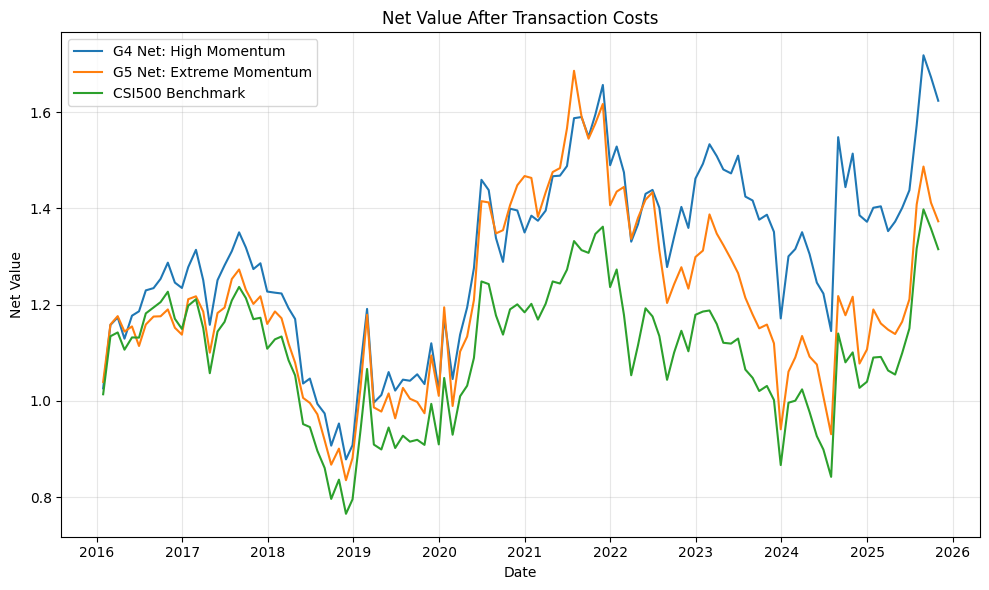

图片已保存： C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\reports\figures\g4_g5_net_value_with_cost.png


In [29]:
# =========================
# Cell 19: G4 / G5 扣费后净值对比
# =========================

# 1. 计算扣费后净值
g4_net_value = (1 + g4_cost_result["net_return"]).cumprod()
g5_net_value = (1 + g5_cost_result["net_return"]).cumprod()

# 2. 计算中证500基准净值
# benchmark_ret 是之前已经构造好的中证500月度收益序列
benchmark_net_value = (1 + benchmark_ret).cumprod()

# 3. 对齐日期，防止画图时日期错位
common_dates = (
    g4_net_value.index
    .intersection(g5_net_value.index)
    .intersection(benchmark_net_value.index)
)

g4_net_value_plot = g4_net_value.loc[common_dates]
g5_net_value_plot = g5_net_value.loc[common_dates]
benchmark_net_value_plot = benchmark_net_value.loc[common_dates]

# 4. 画图
plt.figure(figsize=(10, 6))

plt.plot(g4_net_value_plot.index, g4_net_value_plot, label="G4 Net: High Momentum")
plt.plot(g5_net_value_plot.index, g5_net_value_plot, label="G5 Net: Extreme Momentum")
plt.plot(benchmark_net_value_plot.index, benchmark_net_value_plot, label="CSI500 Benchmark")

plt.title("Net Value After Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Net Value")
plt.legend()
plt.grid(True, alpha=0.3)

# 5. 保存图片
plt.tight_layout()
plt.savefig(FIGURE_DIR / "g4_g5_net_value_with_cost.png", dpi=300)
plt.show()

print("图片已保存：", FIGURE_DIR / "g4_g5_net_value_with_cost.png")

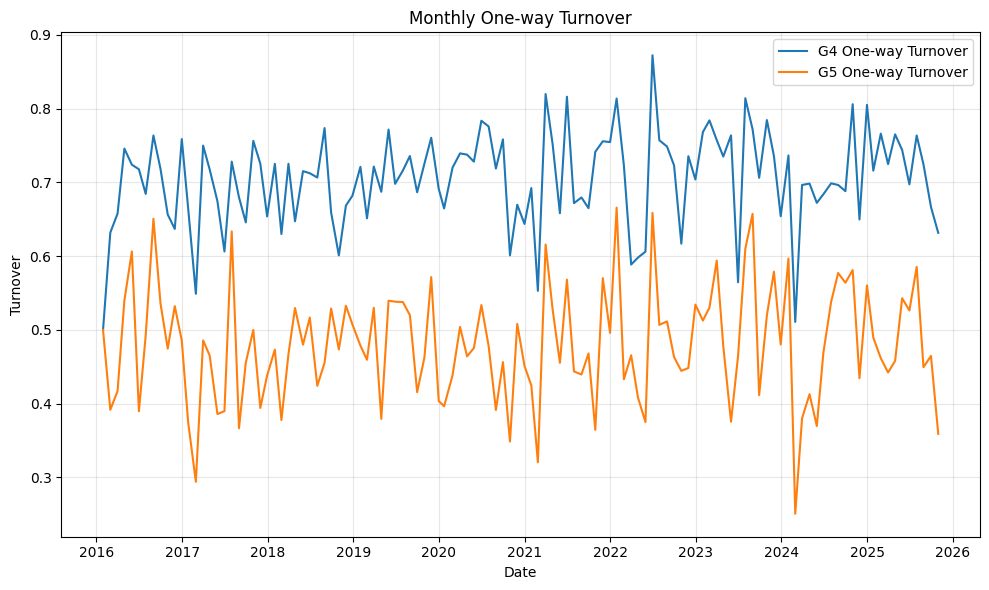

图片已保存： C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\reports\figures\g4_g5_monthly_turnover.png


In [30]:
# =========================
# Cell 20: G4 / G5 月度换手率对比
# =========================

# 1. 提取单边换手率
g4_turnover = g4_cost_result["one_way_turnover"]
g5_turnover = g5_cost_result["one_way_turnover"]

# 2. 对齐日期
common_dates = g4_turnover.index.intersection(g5_turnover.index)

g4_turnover_plot = g4_turnover.loc[common_dates]
g5_turnover_plot = g5_turnover.loc[common_dates]

# 3. 画图
plt.figure(figsize=(10, 6))

plt.plot(g4_turnover_plot.index, g4_turnover_plot, label="G4 One-way Turnover")
plt.plot(g5_turnover_plot.index, g5_turnover_plot, label="G5 One-way Turnover")

plt.title("Monthly One-way Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.legend()
plt.grid(True, alpha=0.3)

# 4. 保存图片
plt.tight_layout()
plt.savefig(FIGURE_DIR / "g4_g5_monthly_turnover.png", dpi=300)
plt.show()

print("图片已保存：", FIGURE_DIR / "g4_g5_monthly_turnover.png")

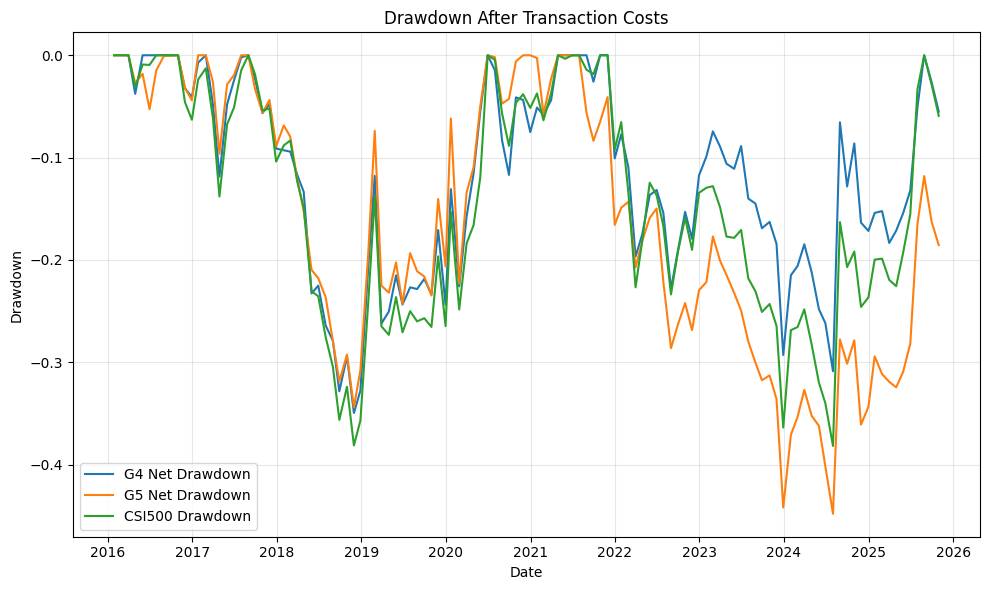

图片已保存： C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\reports\figures\g4_g5_drawdown_with_cost.png


In [31]:
# =========================
# Cell 21: G4 / G5 扣费后回撤对比
# =========================

def calculate_drawdown(net_value):
    """
    根据净值曲线计算回撤序列。
    
    回撤 = 当前净值 / 历史最高净值 - 1
    """
    running_max = net_value.cummax()
    drawdown = net_value / running_max - 1
    return drawdown


# 1. 计算回撤
g4_drawdown = calculate_drawdown(g4_net_value_plot)
g5_drawdown = calculate_drawdown(g5_net_value_plot)
benchmark_drawdown = calculate_drawdown(benchmark_net_value_plot)

# 2. 画图
plt.figure(figsize=(10, 6))

plt.plot(g4_drawdown.index, g4_drawdown, label="G4 Net Drawdown")
plt.plot(g5_drawdown.index, g5_drawdown, label="G5 Net Drawdown")
plt.plot(benchmark_drawdown.index, benchmark_drawdown, label="CSI500 Drawdown")

plt.title("Drawdown After Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True, alpha=0.3)

# 3. 保存图片
plt.tight_layout()
plt.savefig(FIGURE_DIR / "g4_g5_drawdown_with_cost.png", dpi=300)
plt.show()

print("图片已保存：", FIGURE_DIR / "g4_g5_drawdown_with_cost.png")

In [32]:
# =========================
# Cell 22: 生成阶段性研究摘要
# =========================

report_path = ROOT / "reports" / "momentum_strategy_report.md"

summary_text = f"""
# A股横截面动量策略研究报告

## 1. 数据与策略设定

- 股票池：中证500成分股
- 样本区间：2016-01 至 2025-12
- 因子：过去60日收益率，剔除最近5日收益率，即 momentum_60_5
- 调仓频率：月度调仓
- 分组方法：每月按因子值从低到高分为5组
- G4：动量排名 60%-80% 的股票组合
- G5：动量排名 80%-100% 的极端高动量股票组合
- 组合构造：等权持有
- 交易成本假设：每交易1元资产成本为0.1%

## 2. 主要发现

1. 简单极端动量组 G5 并未表现出稳定的最优收益。
2. G4 组合在样本期内表现优于 G5，说明中证500成分股中可能存在“温和动量优于极端动量”的现象。
3. 扣除交易成本后，G4 的总收益、年化收益和夏普比率仍然高于 G5。
4. G4 的平均换手率高于 G5，说明其收益对交易成本假设更敏感。
5. 当前结果仍需要进一步通过参数稳健性检验和不同股票池检验验证。

## 3. 扣费后绩效结果

{cost_perf.to_markdown(index=False)}

## 4. 换手率结果

{turnover_summary.to_markdown()}

## 5. 图表

- `reports/figures/g4_g5_net_value_with_cost.png`
- `reports/figures/g4_g5_monthly_turnover.png`
- `reports/figures/g4_g5_drawdown_with_cost.png`

## 6. 后续工作

- 测试不同动量窗口：20日、60日、120日
- 测试不同跳过窗口：0日、5日、20日
- 测试不同股票池：沪深300、中证500、中证1000
- 加入行业/市值中性化处理
- 比较动量、反转和波动率因子
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("研究报告已保存：", report_path)

研究报告已保存： C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\reports\momentum_strategy_report.md


In [33]:
# =========================
# Cell 23: 读取多窗口动量因子数据
# =========================

multi_path = ROOT / "data" / "raw" / "factor_return_panel_multi_window.csv"

print("文件路径：", multi_path)
print("文件是否存在：", multi_path.exists())

multi_df = pd.read_csv(multi_path, encoding="utf-8-sig")

# 转换日期格式
multi_df["signal_date"] = pd.to_datetime(multi_df["signal_date"])
multi_df["entry_date"] = pd.to_datetime(multi_df["entry_date"])
multi_df["exit_date"] = pd.to_datetime(multi_df["exit_date"])

print("数据形状：", multi_df.shape)
print("列名：")
print(multi_df.columns)

display(multi_df.head())

文件路径： C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\data\raw\factor_return_panel_multi_window.csv
文件是否存在： True
数据形状： (57865, 9)
列名：
Index(['signal_date', 'entry_date', 'exit_date', 'code', 'next_ret',
       'benchmark_ret', 'momentum_20_5', 'momentum_60_5', 'momentum_120_5'],
      dtype='object')


,signal_date,entry_date,exit_date,code,next_ret,benchmark_ret,momentum_20_5,momentum_60_5,momentum_120_5
0,2016-01-29,2016-02-01,2016-03-01,000006.XSHE,0.133913,0.013733,-0.204545,-0.320041,-0.309450
1,2016-01-29,2016-02-01,2016-03-01,000012.XSHE,-0.025907,0.013733,-0.162003,-0.064145,-0.176556
2,2016-01-29,2016-02-01,2016-03-01,000021.XSHE,0.010929,0.013733,-0.181181,-0.265709,-0.223909
3,2016-01-29,2016-02-01,2016-03-01,000030.XSHE,-0.034188,0.013733,-0.203426,-0.218487,-0.439759
4,2016-01-29,2016-02-01,2016-03-01,000031.XSHE,0.162011,0.013733,-0.159798,-0.312457,-0.417153


In [34]:
# =========================
# Cell 24: 通用因子分组函数
# =========================

def assign_groups_by_factor(group, factor_col, n_groups=5):
    """
    对某一个信号日的股票，按照指定因子分成 n_groups 组。
    
    参数：
    group      : 某一个 signal_date 下的所有股票
    factor_col : 因子列名，例如 momentum_20_5
    n_groups   : 分成几组，默认5组
    
    返回：
    增加 factor_group 列后的数据
    """
    
    group = group.copy()
    
    # 如果该月股票太少，无法分组
    if len(group) < n_groups:
        group["factor_group"] = np.nan
        return group
    
    # 用 rank 处理重复值问题
    rank_value = group[factor_col].rank(method="first", ascending=True)
    
    labels = [f"G{i}" for i in range(1, n_groups + 1)]
    
    group["factor_group"] = pd.qcut(
        rank_value,
        q=n_groups,
        labels=labels
    )
    
    return group

In [35]:
# =========================
# Cell 25: 单个因子的稳健性检验函数
# =========================

def run_single_factor_test(data, factor_col, cost_rate=0.001):
    """
    对单个动量因子做完整测试。
    
    包括：
    1. 按因子分组；
    2. 计算分组收益；
    3. 构造 G4/G5 等权组合；
    4. 计算交易成本和换手率；
    5. 输出绩效结果。
    """
    
    # 只保留当前因子不缺失、下一期收益不缺失的样本
    temp = data.dropna(subset=[factor_col, "next_ret"]).copy()
    
    # 每个月按当前因子分组
    grouped = (
        temp.groupby("signal_date", group_keys=False)
        .apply(lambda x: assign_groups_by_factor(x, factor_col, n_groups=5))
        .dropna(subset=["factor_group"])
    )
    
    # 计算每个月每组的平均收益
    group_ret = (
        grouped
        .groupby(["signal_date", "factor_group"], observed=False)["next_ret"]
        .mean()
        .unstack()
        .sort_index()
    )
    
    # 计算 RankIC
    def calc_rank_ic_one_month(x):
        if len(x) < 20:
            return np.nan
        if x[factor_col].nunique() <= 1 or x["next_ret"].nunique() <= 1:
            return np.nan
        return x[factor_col].corr(x["next_ret"], method="spearman")
    
    rank_ic = grouped.groupby("signal_date").apply(calc_rank_ic_one_month)
    
    # 构造收益矩阵
    ret_matrix_temp = grouped.pivot(
        index="signal_date",
        columns="code",
        values="next_ret"
    )
    
    # 构造 G4/G5 持仓
    g4_weights_temp = build_equal_weight_portfolio(grouped, "G4")
    g5_weights_temp = build_equal_weight_portfolio(grouped, "G5")
    
    # 计算扣费结果
    g4_result = calculate_turnover_and_cost(
        g4_weights_temp,
        ret_matrix_temp,
        cost_rate=cost_rate
    )
    
    g5_result = calculate_turnover_and_cost(
        g5_weights_temp,
        ret_matrix_temp,
        cost_rate=cost_rate
    )
    
    # 计算绩效
    g4_net_perf = performance_summary(
        g4_result["net_return"],
        f"{factor_col}_G4_net"
    )
    
    g5_net_perf = performance_summary(
        g5_result["net_return"],
        f"{factor_col}_G5_net"
    )
    
    # 汇总核心指标
    summary = {
        "factor": factor_col,
        
        # 分组平均月收益
        "G1_avg_monthly_ret": group_ret["G1"].mean(),
        "G2_avg_monthly_ret": group_ret["G2"].mean(),
        "G3_avg_monthly_ret": group_ret["G3"].mean(),
        "G4_avg_monthly_ret": group_ret["G4"].mean(),
        "G5_avg_monthly_ret": group_ret["G5"].mean(),
        
        # RankIC
        "rank_ic_mean": rank_ic.mean(),
        "rank_ic_positive_ratio": (rank_ic > 0).mean(),
        
        # G4 扣费后绩效
        "G4_net_annual_return": g4_net_perf["annual_return"],
        "G4_net_sharpe": g4_net_perf["sharpe"],
        "G4_net_max_drawdown": g4_net_perf["max_drawdown"],
        "G4_avg_one_way_turnover": g4_result["one_way_turnover"].mean(),
        
        # G5 扣费后绩效
        "G5_net_annual_return": g5_net_perf["annual_return"],
        "G5_net_sharpe": g5_net_perf["sharpe"],
        "G5_net_max_drawdown": g5_net_perf["max_drawdown"],
        "G5_avg_one_way_turnover": g5_result["one_way_turnover"].mean(),
    }
    
    return summary, group_ret, rank_ic, g4_result, g5_result

In [36]:
# =========================
# Cell 26: 对 20/60/120 日动量窗口做稳健性检验
# =========================

factor_list = [
    "momentum_20_5",
    "momentum_60_5",
    "momentum_120_5"
]

robustness_summaries = []
robustness_details = {}

for factor_col in factor_list:
    print(f"Running robustness test for: {factor_col}")
    
    summary, group_ret, rank_ic, g4_result, g5_result = run_single_factor_test(
        multi_df,
        factor_col=factor_col,
        cost_rate=0.001
    )
    
    robustness_summaries.append(summary)
    
    robustness_details[factor_col] = {
        "group_return": group_ret,
        "rank_ic": rank_ic,
        "g4_result": g4_result,
        "g5_result": g5_result
    }

robustness_summary = pd.DataFrame(robustness_summaries)

display(robustness_summary)

Running robustness test for: momentum_20_5


C:\Users\yue\AppData\Local\Temp\ipykernel_27756\4081472256.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: assign_groups_by_factor(x, factor_col, n_groups=5))
C:\Users\yue\AppData\Local\Temp\ipykernel_27756\4081472256.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank_ic = grouped.groupby("signal_date").apply(calc_rank_ic_one_month)


Running robustness test for: momentum_60_5


C:\Users\yue\AppData\Local\Temp\ipykernel_27756\4081472256.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: assign_groups_by_factor(x, factor_col, n_groups=5))
C:\Users\yue\AppData\Local\Temp\ipykernel_27756\4081472256.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank_ic = grouped.groupby("signal_date").apply(calc_rank_ic_one_month)


Running robustness test for: momentum_120_5


C:\Users\yue\AppData\Local\Temp\ipykernel_27756\4081472256.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: assign_groups_by_factor(x, factor_col, n_groups=5))
C:\Users\yue\AppData\Local\Temp\ipykernel_27756\4081472256.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rank_ic = grouped.groupby("signal_date").apply(calc_rank_ic_one_month)


,factor,G1_avg_monthly_ret,G2_avg_monthly_ret,G3_avg_monthly_ret,G4_avg_monthly_ret,G5_avg_monthly_ret,rank_ic_mean,rank_ic_positive_ratio,G4_net_annual_return,G4_net_sharpe,G4_net_max_drawdown,G4_avg_one_way_turnover,G5_net_annual_return,G5_net_sharpe,G5_net_max_drawdown,G5_avg_one_way_turnover
0,momentum_20_5,0.005824,0.006625,0.007625,0.006718,0.005913,-0.018641,0.466102,0.037024,0.161425,-0.421154,0.800178,0.026646,0.114259,-0.402271,0.761712
1,momentum_60_5,0.005352,0.006555,0.007209,0.007603,0.005984,-0.023210,0.457627,0.050583,0.221310,-0.349580,0.704680,0.032651,0.135203,-0.448057,0.479458
2,momentum_120_5,0.003474,0.005023,0.007376,0.009889,0.006961,-0.001868,0.508475,0.083911,0.377467,-0.320624,0.599397,0.050404,0.218246,-0.433285,0.351989


In [37]:
# =========================
# Cell 27: 保存稳健性检验结果
# =========================

robustness_summary.to_csv(
    PROCESSED_DIR / "robustness_momentum_windows.csv",
    index=False,
    encoding="utf-8-sig"
)

print("稳健性检验结果已保存：")
print(PROCESSED_DIR / "robustness_momentum_windows.csv")

稳健性检验结果已保存：
C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\data\processed\robustness_momentum_windows.csv


In [38]:
# =========================
# Cell 28: 读取稳健性检验结果
# =========================

robustness_path = PROCESSED_DIR / "robustness_momentum_windows.csv"

robustness_summary = pd.read_csv(robustness_path, encoding="utf-8-sig")

display(robustness_summary)

,factor,G1_avg_monthly_ret,G2_avg_monthly_ret,G3_avg_monthly_ret,G4_avg_monthly_ret,G5_avg_monthly_ret,rank_ic_mean,rank_ic_positive_ratio,G4_net_annual_return,G4_net_sharpe,G4_net_max_drawdown,G4_avg_one_way_turnover,G5_net_annual_return,G5_net_sharpe,G5_net_max_drawdown,G5_avg_one_way_turnover
0,momentum_20_5,0.005824,0.006625,0.007625,0.006718,0.005913,-0.018641,0.466102,0.037024,0.161425,-0.421154,0.800178,0.026646,0.114259,-0.402271,0.761712
1,momentum_60_5,0.005352,0.006555,0.007209,0.007603,0.005984,-0.023210,0.457627,0.050583,0.221310,-0.349580,0.704680,0.032651,0.135203,-0.448057,0.479458
2,momentum_120_5,0.003474,0.005023,0.007376,0.009889,0.006961,-0.001868,0.508475,0.083911,0.377467,-0.320624,0.599397,0.050404,0.218246,-0.433285,0.351989


In [39]:
# =========================
# Cell 29: 整理画图标签
# =========================

plot_df = robustness_summary.copy()

# 把 momentum_20_5 变成 20/5
plot_df["window_label"] = plot_df["factor"].str.replace("momentum_", "", regex=False)

display(plot_df[["factor", "window_label"]])

,factor,window_label
0,momentum_20_5,20_5
1,momentum_60_5,60_5
2,momentum_120_5,120_5


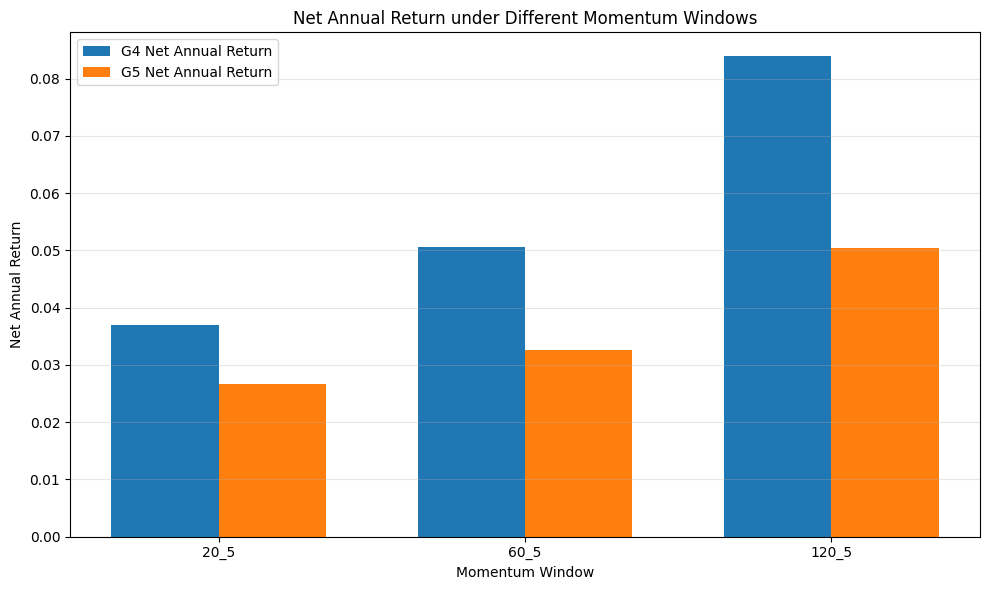

图片已保存： C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\reports\figures\robustness_net_annual_return.png


In [40]:
# =========================
# Cell 30: 不同窗口下 G4/G5 扣费后年化收益对比
# =========================

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    plot_df["G4_net_annual_return"],
    width,
    label="G4 Net Annual Return"
)

plt.bar(
    x + width / 2,
    plot_df["G5_net_annual_return"],
    width,
    label="G5 Net Annual Return"
)

plt.xticks(x, plot_df["window_label"])
plt.title("Net Annual Return under Different Momentum Windows")
plt.xlabel("Momentum Window")
plt.ylabel("Net Annual Return")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "robustness_net_annual_return.png", dpi=300)
plt.show()

print("图片已保存：", FIGURE_DIR / "robustness_net_annual_return.png")

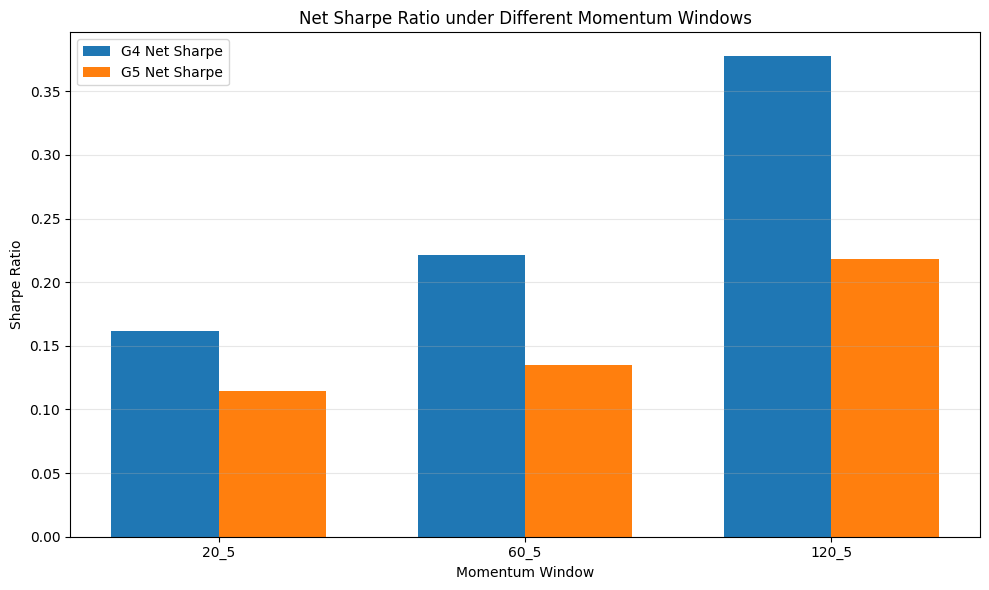

图片已保存： C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\reports\figures\robustness_net_sharpe.png


In [41]:
# =========================
# Cell 31: 不同窗口下 G4/G5 夏普比率对比
# =========================

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    plot_df["G4_net_sharpe"],
    width,
    label="G4 Net Sharpe"
)

plt.bar(
    x + width / 2,
    plot_df["G5_net_sharpe"],
    width,
    label="G5 Net Sharpe"
)

plt.xticks(x, plot_df["window_label"])
plt.title("Net Sharpe Ratio under Different Momentum Windows")
plt.xlabel("Momentum Window")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "robustness_net_sharpe.png", dpi=300)
plt.show()

print("图片已保存：", FIGURE_DIR / "robustness_net_sharpe.png")

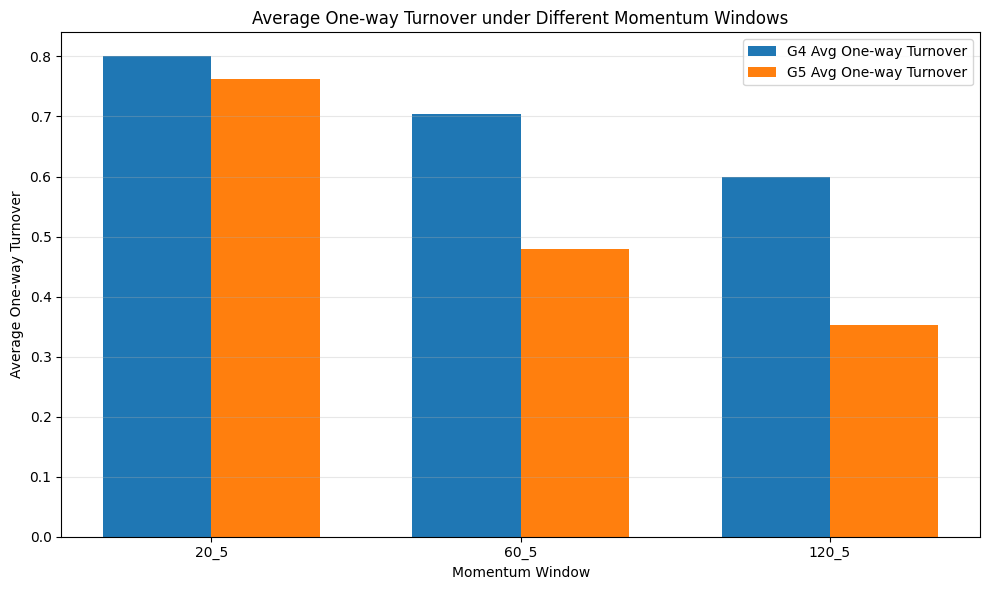

图片已保存： C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\reports\figures\robustness_turnover.png


In [42]:
# =========================
# Cell 32: 不同窗口下 G4/G5 平均单边换手率对比
# =========================

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    plot_df["G4_avg_one_way_turnover"],
    width,
    label="G4 Avg One-way Turnover"
)

plt.bar(
    x + width / 2,
    plot_df["G5_avg_one_way_turnover"],
    width,
    label="G5 Avg One-way Turnover"
)

plt.xticks(x, plot_df["window_label"])
plt.title("Average One-way Turnover under Different Momentum Windows")
plt.xlabel("Momentum Window")
plt.ylabel("Average One-way Turnover")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "robustness_turnover.png", dpi=300)
plt.show()

print("图片已保存：", FIGURE_DIR / "robustness_turnover.png")

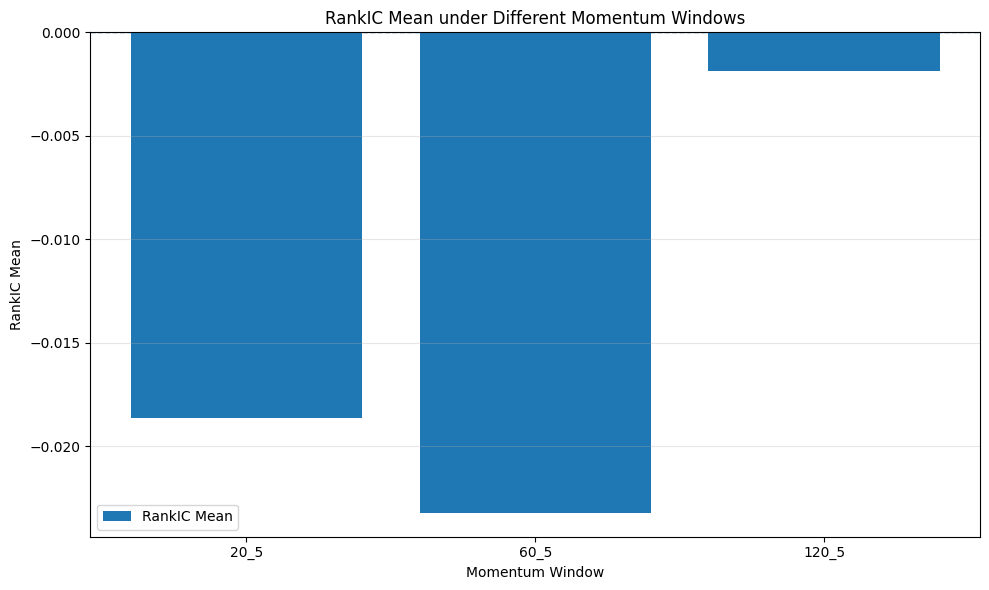

图片已保存： C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\reports\figures\robustness_rank_ic.png


In [43]:
# =========================
# Cell 33: 不同窗口下 RankIC 均值对比
# =========================

plt.figure(figsize=(10, 6))

plt.bar(
    plot_df["window_label"],
    plot_df["rank_ic_mean"],
    label="RankIC Mean"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("RankIC Mean under Different Momentum Windows")
plt.xlabel("Momentum Window")
plt.ylabel("RankIC Mean")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "robustness_rank_ic.png", dpi=300)
plt.show()

print("图片已保存：", FIGURE_DIR / "robustness_rank_ic.png")

In [44]:
# =========================
# Cell 34: 更新研究报告，加入稳健性检验
# =========================

report_path = ROOT / "reports" / "momentum_strategy_report.md"

robustness_section = f"""

## 7. 参数稳健性检验：不同动量窗口

为了检验结论是否依赖单一参数设定，本项目进一步比较了三种动量窗口：

- `momentum_20_5`：过去20日收益率，剔除最近5日；
- `momentum_60_5`：过去60日收益率，剔除最近5日；
- `momentum_120_5`：过去120日收益率，剔除最近5日。

### 7.1 稳健性结果表

{robustness_summary.to_markdown(index=False)}

### 7.2 主要结论

1. 在 20日、60日、120日三个动量窗口下，G4 组合的扣费后年化收益均高于 G5 组合。
2. 在三个窗口下，G4 组合的扣费后夏普比率也均高于 G5，说明 G4 的收益风险比更优。
3. 随着动量窗口从20日延长至120日，组合换手率下降，交易成本压力减弱。
4. RankIC 均值整体较弱，说明该动量因子并不表现为稳定的单调排序因子。
5. 综合来看，中证500成分股中更明显的现象不是“极端动量持续占优”，而是“温和高动量组合优于极端高动量组合”。

### 7.3 稳健性图表

- `reports/figures/robustness_net_annual_return.png`
- `reports/figures/robustness_net_sharpe.png`
- `reports/figures/robustness_turnover.png`
- `reports/figures/robustness_rank_ic.png`
"""

# 以追加模式写入报告末尾
with open(report_path, "a", encoding="utf-8") as f:
    f.write(robustness_section)

print("研究报告已更新：", report_path)

研究报告已更新： C:\Users\yue\Desktop\A-Share-Momentum-Strategy-Research\reports\momentum_strategy_report.md
